<a href="https://colab.research.google.com/github/fabiansteinmetz/CS156/blob/main/CS156_Session_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import statsmodels.api as sm

# Load data
train = pd.read_csv('train.csv')

# 1. Build dataframe with dependent variable Fare and three independent variables:
# Pclass (passenger class), Age, SibSp (num siblings/spouses aboard)
df = train[['Fare', 'Pclass', 'Age', 'SibSp']].copy()

print("Missing values before dropna:")
print(df.isna().sum())

df = df.dropna()
print(f"\nRows used after dropping missing values: {len(df)}")
print("\nDataframe head:")
print(df.head())

# 2. Fit linear regression: Fare ~ Pclass + Age + SibSp
X = df[['Pclass', 'Age', 'SibSp']]
X = sm.add_constant(X)
y = df['Fare']

model = sm.OLS(y, X).fit()
print("\n" + "="*60)
print(model.summary())

Missing values before dropna:
Fare        0
Pclass      0
Age       177
SibSp       0
dtype: int64

Rows used after dropping missing values: 714

Dataframe head:
      Fare  Pclass   Age  SibSp
0   7.2500       3  22.0      1
1  71.2833       1  38.0      1
2   7.9250       3  26.0      0
3  53.1000       1  35.0      1
4   8.0500       3  35.0      0

                            OLS Regression Results                            
Dep. Variable:                   Fare   R-squared:                       0.342
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     123.3
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           2.86e-64
Time:                        08:34:49   Log-Likelihood:                -3696.6
No. Observations:                 714   AIC:                             7401.
Df Residuals:                     710   BIC:                             7420.
Df Model:    

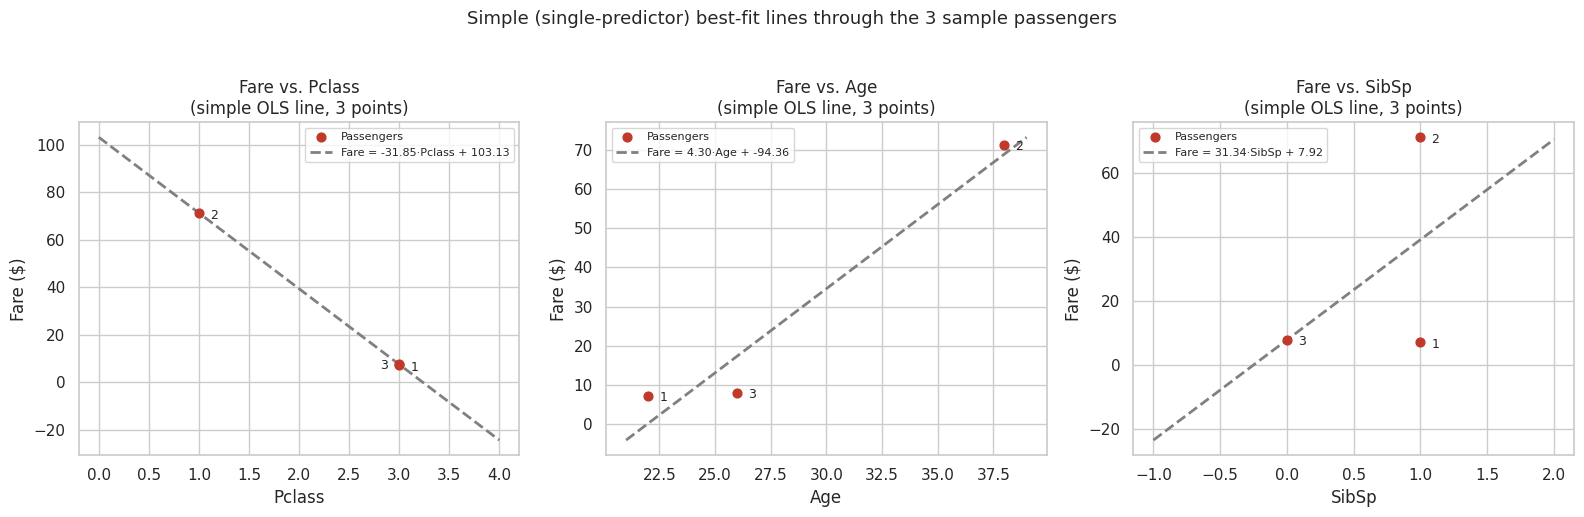

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# The same 3 passengers used in the 3x3 exact-system example
Pclass = np.array([3, 1, 3], dtype=float)
Age    = np.array([22, 38, 26], dtype=float)
SibSp  = np.array([1, 1, 0], dtype=float)
Fare   = np.array([7.25, 71.2833, 7.925], dtype=float)

predictors = {
    "Pclass": Pclass,
    "Age": Age,
    "SibSp": SibSp,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

glob_count = 0
for ax, (name, x) in zip(axes, predictors.items()):
    glob_count += 1
    # simple least-squares line through the 3 points for this one predictor
    slope, intercept = np.polyfit(x, Fare, 1)
    x_line = np.linspace(x.min() - 1, x.max() + 1, 100)
    y_line = slope * x_line + intercept

    ax.scatter(x, Fare, s=40, color="#c0392b", zorder=3, label="Passengers")
    ax.plot(x_line, y_line, linestyle="--", color="gray", linewidth=2,
             label=f"Fare = {slope:.2f}\u00b7{name} + {intercept:.2f}")

    count = 0
    for xi, yi in zip(x, Fare):
      count += 1
      if (count == 3 and glob_count == 1):
        xi -= 0.3
      ax.annotate(f"{count}", (xi , yi), textcoords="offset points",
                    xytext=(8, -4), fontsize=9)

    ax.set_xlabel(name)
    ax.set_ylabel("Fare ($)")
    ax.set_title(f"Fare vs. {name}\n(simple OLS line, 3 points)")
    ax.legend(loc="best", fontsize=8)

fig.suptitle("Simple (single-predictor) best-fit lines through the 3 sample passengers", y=1.03, fontsize=13)
fig.tight_layout()
#fig.savefig("/mnt/user-data/outputs/plot_3points_per_predictor.png", dpi=150, bbox_inches="tight")
plt.show()

const     121.885305
Pclass    -37.387432
Age        -0.272453
SibSp       8.827617
dtype: float64


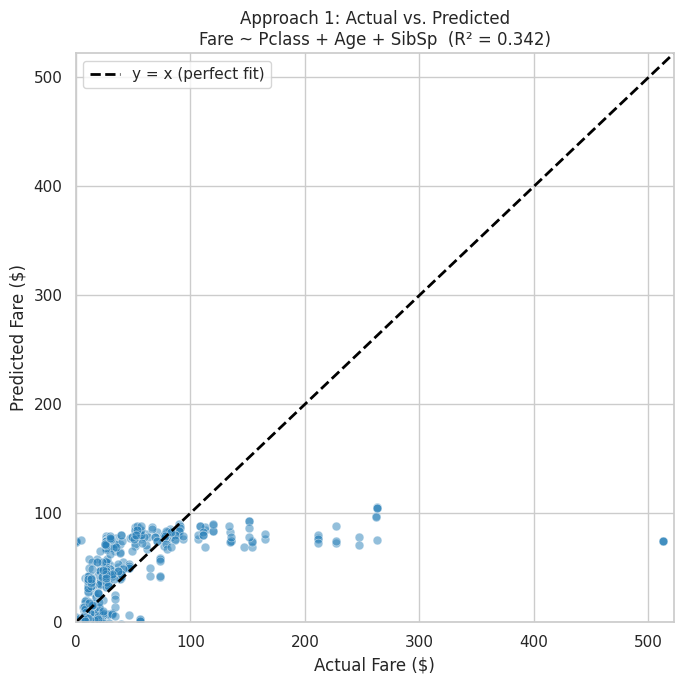

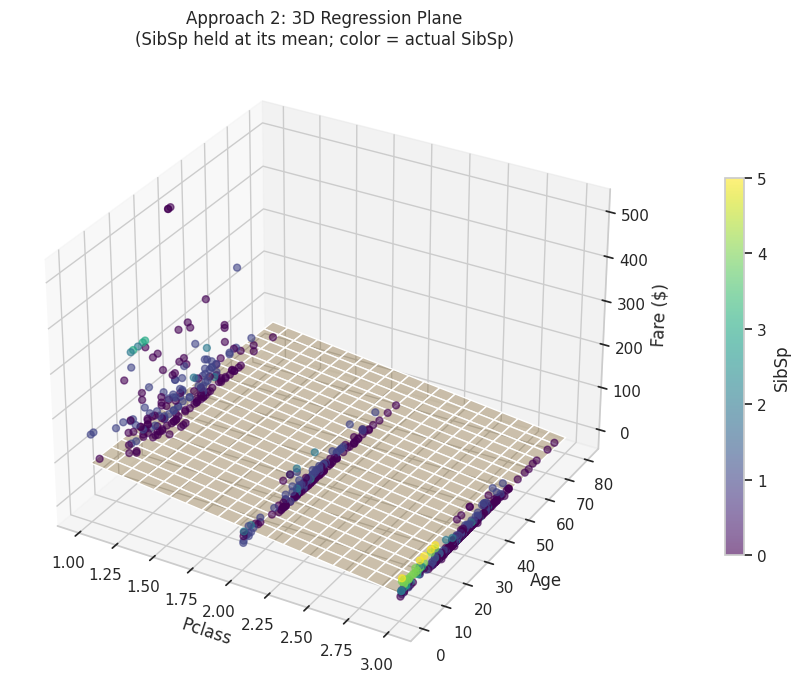

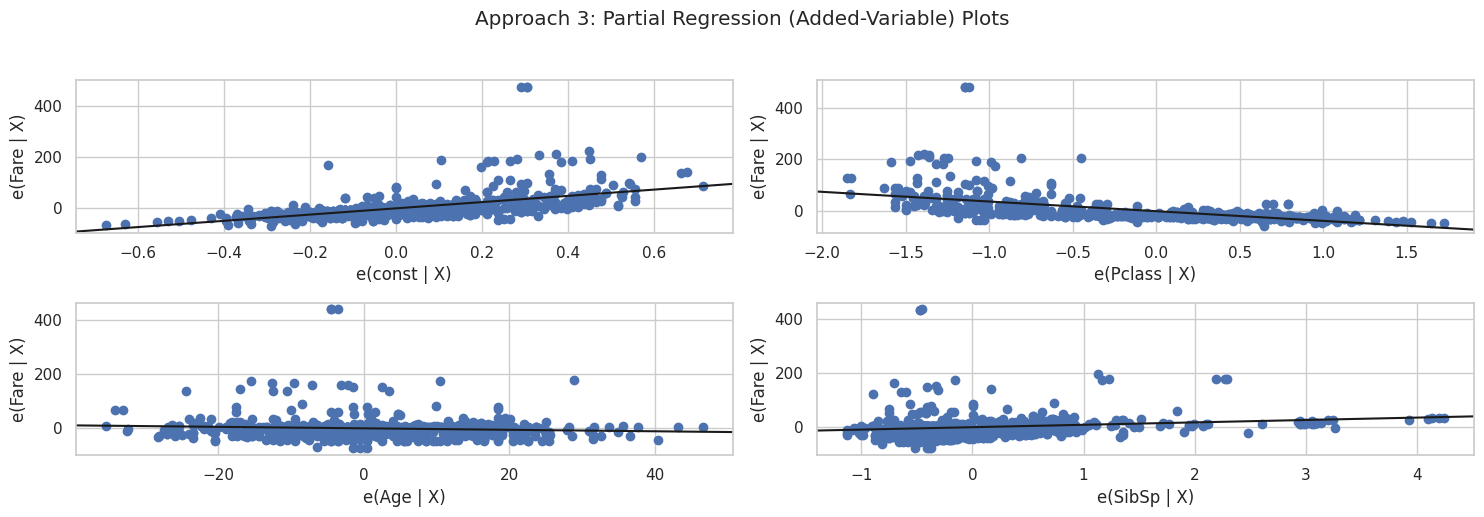

All three plots saved.


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3D projection)

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------------
# Load data & fit the full multivariate model
# ---------------------------------------------------------------
train = pd.read_csv('train.csv')
df = train[['Fare', 'Pclass', 'Age', 'SibSp']].dropna()

X = sm.add_constant(df[['Pclass', 'Age', 'SibSp']])
y = df['Fare']
model = sm.OLS(y, X).fit()
r2 = model.rsquared
print(model.params)

# =================================================================
# APPROACH 1: Actual vs. Predicted (works for ANY number of predictors)
# =================================================================
fitted = model.fittedvalues

fig1, ax1 = plt.subplots(figsize=(7, 7))
sns.scatterplot(x=y, y=fitted, alpha=0.5, s=40, color="#2980b9", ax=ax1)
lims = [0, max(y.max(), fitted.max()) + 10]
ax1.plot(lims, lims, linestyle="--", color="black", linewidth=2, label="y = x (perfect fit)")
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel("Actual Fare ($)")
ax1.set_ylabel("Predicted Fare ($)")
ax1.set_title(f"Approach 1: Actual vs. Predicted\nFare ~ Pclass + Age + SibSp  (R\u00b2 = {r2:.3f})")
ax1.legend()
fig1.tight_layout()


# =================================================================
# APPROACH 2: 3D regression plane using 2 of the 3 predictors
# (Pclass, Age -> Fare), with SibSp shown via point color
# =================================================================
fig2 = plt.figure(figsize=(9, 7))
ax2 = fig2.add_subplot(111, projection="3d")

sc = ax2.scatter(df["Pclass"], df["Age"], df["Fare"],
                  c=df["SibSp"], cmap="viridis", alpha=0.6, s=25)

# Build a grid over Pclass/Age, holding SibSp at its mean, to draw the fitted plane
pclass_range = np.linspace(df["Pclass"].min(), df["Pclass"].max(), 20)
age_range = np.linspace(df["Age"].min(), df["Age"].max(), 20)
Pgrid, Agrid = np.meshgrid(pclass_range, age_range)
sibsp_mean = df["SibSp"].mean()

Fare_pred = (model.params["const"]
             + model.params["Pclass"] * Pgrid
             + model.params["Age"] * Agrid
             + model.params["SibSp"] * sibsp_mean)

ax2.plot_surface(Pgrid, Agrid, Fare_pred, alpha=0.3, color="orange")

ax2.set_xlabel("Pclass")
ax2.set_ylabel("Age")
ax2.set_zlabel("Fare ($)")
ax2.set_title("Approach 2: 3D Regression Plane\n(SibSp held at its mean; color = actual SibSp)")
cbar = fig2.colorbar(sc, ax=ax2, shrink=0.6, pad=0.1)
cbar.set_label("SibSp")
fig2.tight_layout()
#fig2.savefig("/mnt/user-data/outputs/approach2_3d_plane.png", dpi=150)


# =================================================================
# APPROACH 3: Partial regression (added-variable) plots
# Shows each predictor's TRUE multivariate slope after controlling
# for the other two -- this is the rigorous per-variable "line of
# best fit" for a multivariate model.
# =================================================================
fig3 = plt.figure(figsize=(15, 5))
sm.graphics.plot_partregress_grid(model, fig=fig3)
fig3.suptitle("Approach 3: Partial Regression (Added-Variable) Plots", y=1.03)
fig3.tight_layout()
#fig3.savefig("/mnt/user-data/outputs/approach3_partial_regression.png", dpi=150, bbox_inches="tight")
plt.show()

print("All three plots saved.")

In [29]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

train = pd.read_csv('train.csv')
df = train[['Fare', 'Pclass', 'Age', 'SibSp']].dropna()

X = sm.add_constant(df[['Pclass', 'Age', 'SibSp']])
y = df['Fare']
model = sm.OLS(y, X).fit()

# SSR directly
print("SSR:", model.ssr)

# or manually, matching the vector-space definition e^T e
resid = model.resid.to_numpy()
ssr_manual = resid @ resid
print("SSR (manual, e^T e):", ssr_manual)

SSR: 1312882.8385698094
SSR (manual, e^T e): 1312882.8385698094
